In [84]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
df = pd.read_csv('dataset/german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
# analysis -> feature eng -> model training -> web app

In [86]:
df.drop(columns=df.columns[0],inplace=True)
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [88]:
df['Job'].value_counts()

Job
2    630
1    200
3    148
0     22
Name: count, dtype: int64

In [8]:
df['Saving accounts'].value_counts()

Saving accounts
little        603
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

In [89]:
for obj in df.select_dtypes(include='object').columns:
    print("*"*30)
    print(df[str(obj)].value_counts())

******************************
Sex
male      690
female    310
Name: count, dtype: int64
******************************
Housing
own     713
rent    179
free    108
Name: count, dtype: int64
******************************
Saving accounts
little        603
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64
******************************
Checking account
little      274
moderate    269
rich         63
Name: count, dtype: int64
******************************
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64
******************************
Risk
good    700
bad     300
Name: count, dtype: int64


In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
# sns.pairplot(df)

In [91]:
df.isna().sum()[df.isna().sum()>0]

Saving accounts     183
Checking account    394
dtype: int64

In [92]:
df['Saving accounts'].mode()
df['Saving accounts'] = df['Saving accounts'].fillna(df['Saving accounts'].mode()[0])

In [93]:
df['Checking account'].mode()
df['Checking account'] = df['Checking account'].fillna(df['Checking account'].mode()[0])

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   1000 non-null   object
 5   Checking account  1000 non-null   object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [95]:
for obj in df.select_dtypes(include='object').columns:
    print("*"*30)
    print(df[str(obj)].value_counts())

******************************
Sex
male      690
female    310
Name: count, dtype: int64
******************************
Housing
own     713
rent    179
free    108
Name: count, dtype: int64
******************************
Saving accounts
little        786
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64
******************************
Checking account
little      668
moderate    269
rich         63
Name: count, dtype: int64
******************************
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64
******************************
Risk
good    700
bad     300
Name: count, dtype: int64


In [16]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [17]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,1000,4,little,786,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,1000,3,little,668,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Risk,1000,2,good,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [96]:
df.duplicated().sum()

np.int64(0)

In [97]:
df.select_dtypes(include='int')

,Age,Job,Credit amount,Duration
0,67,2,1169,6
1,22,2,5951,48
2,49,1,2096,12
3,45,2,7882,42
4,53,2,4870,24
...,...,...,...,...
995,31,1,1736,12
996,40,3,3857,30
997,38,2,804,12
998,23,2,1845,45


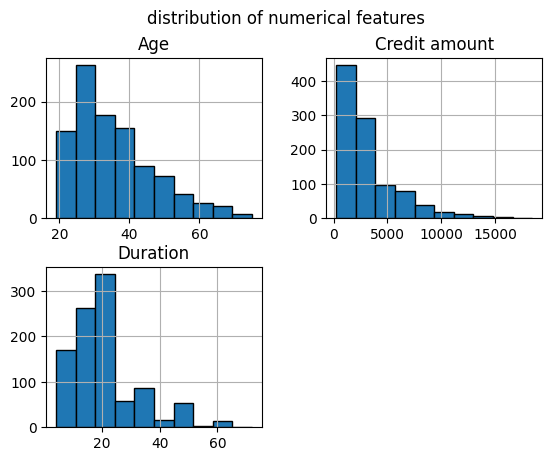

In [98]:
df[['Age','Credit amount','Duration']].hist(bins=10, edgecolor = 'black')
plt.suptitle("distribution of numerical features")
plt.show()

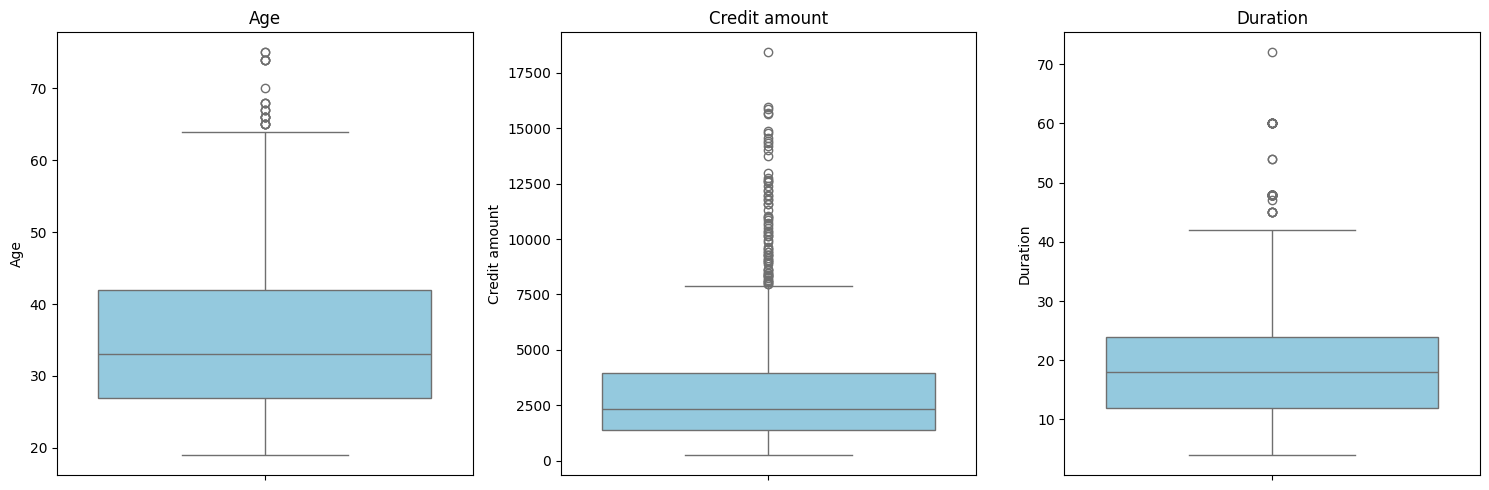

In [99]:
plt.figure(figsize = (15,5))
for i, col in enumerate(['Age','Credit amount','Duration']):
    # print(f"{i}  - {col} ")
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col],color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

In [22]:
df[df['Duration'] >= 60]

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
29,63,male,2,own,little,little,6836,60,business,bad
134,21,female,2,own,moderate,little,10144,60,radio/TV,good
255,27,male,1,own,little,moderate,7418,60,radio/TV,good
332,24,female,3,own,moderate,moderate,7408,60,car,bad
373,63,male,3,free,little,little,13756,60,car,good
374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
616,27,male,3,free,little,moderate,9157,60,radio/TV,good
637,21,male,2,own,little,little,15653,60,radio/TV,good
672,42,male,3,own,little,little,10366,60,car,good
677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


C:\Users\Ann\AppData\Local\Temp\ipykernel_22984\3008258477.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = 'Housing',palette = 'Set2')


<Axes: xlabel='Housing', ylabel='count'>

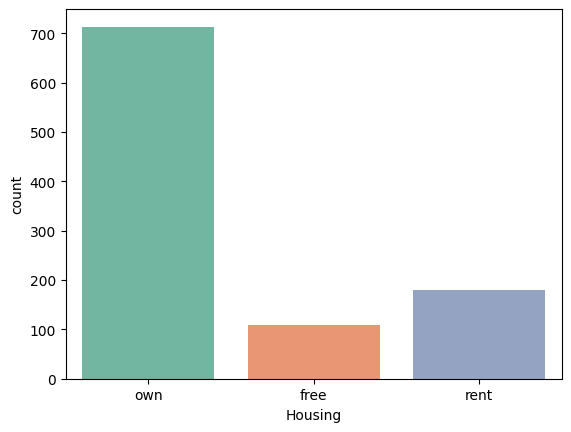

In [100]:
sns.countplot(data = df, x = 'Housing',palette = 'Set2')

C:\Users\Ann\AppData\Local\Temp\ipykernel_22984\3429892764.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = col,palette = 'Set2')
C:\Users\Ann\AppData\Local\Temp\ipykernel_22984\3429892764.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = col,palette = 'Set2')
C:\Users\Ann\AppData\Local\Temp\ipykernel_22984\3429892764.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = col,palette = 'Set2')
C:\Users\Ann\AppData\Local\Temp\ipykernel_22984\3429892764.py:6: FutureWarning: 

Passing `palett

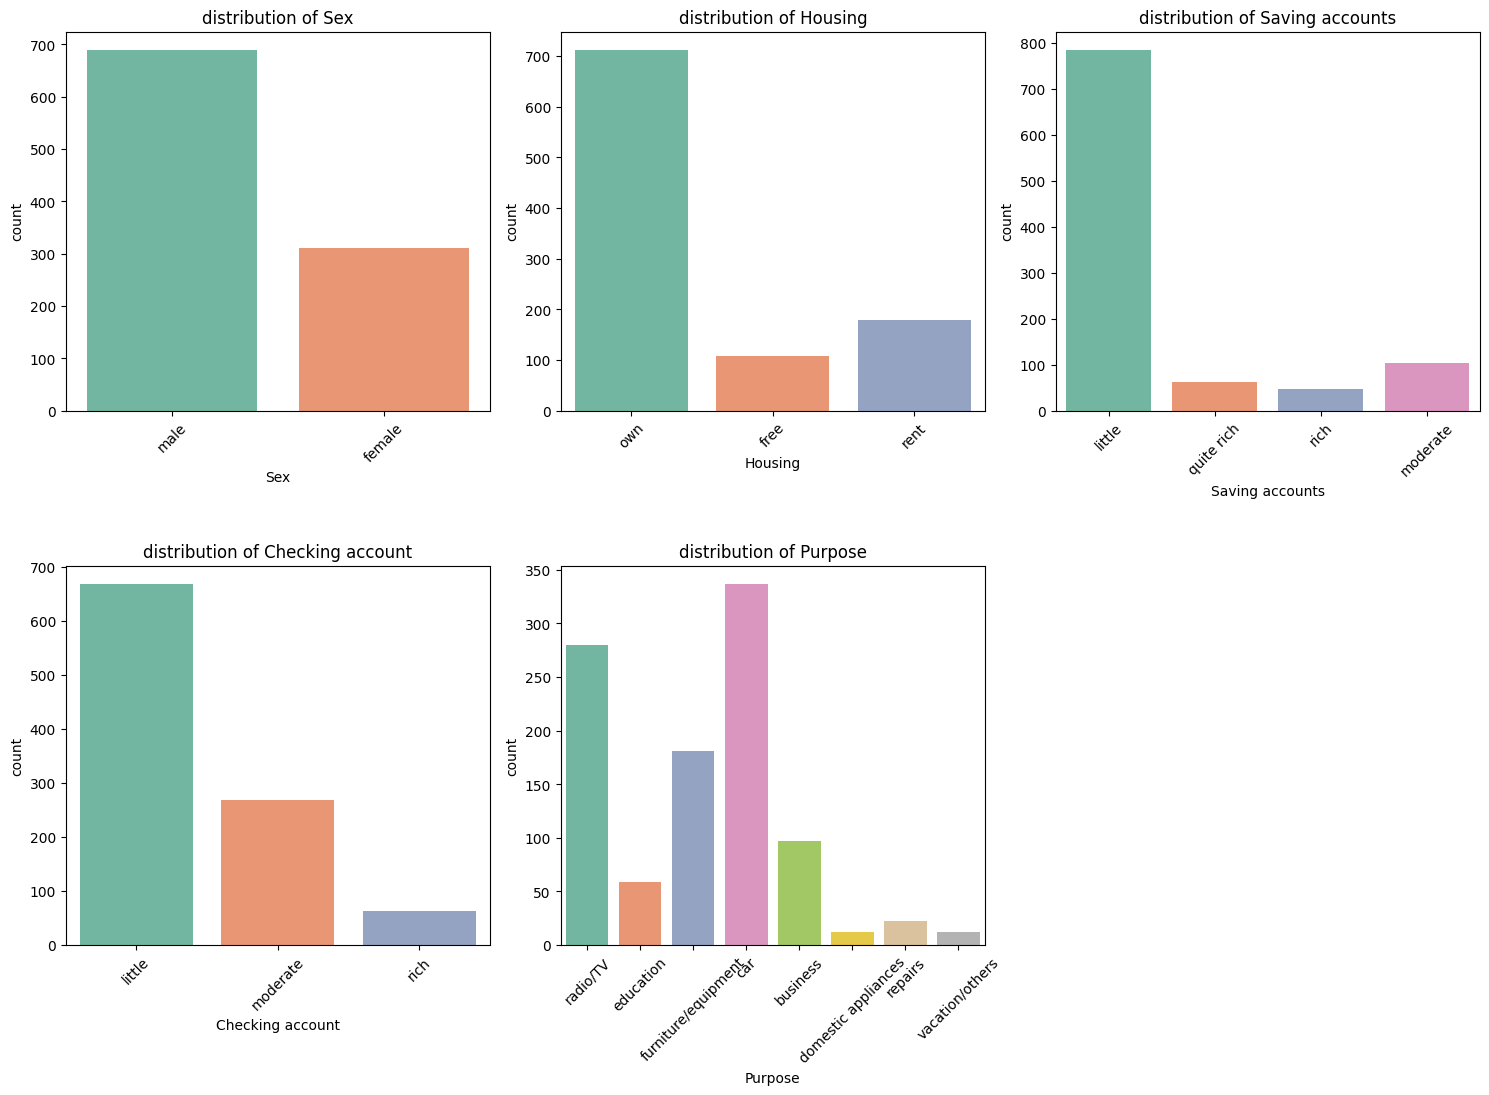

In [101]:
df.select_dtypes(include='object').columns
category_col = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
plt.figure(figsize=(15,15))
for i,col in enumerate(category_col):
    plt.subplot(3,3,i+1)
    sns.countplot(data = df, x = col,palette = 'Set2')
    plt.title(f'distribution of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


<Axes: >

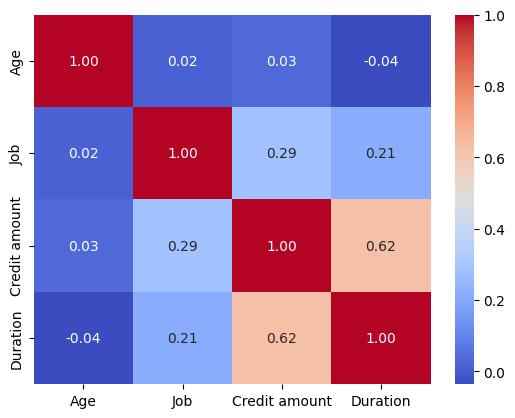

In [102]:
correlation  = df[df.select_dtypes(include='int').columns].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm',fmt='.2f')

In [26]:
df.groupby('Job')['Credit amount'].mean()

Job
0    2745.136364
1    2358.520000
2    3070.965079
3    5435.493243
Name: Credit amount, dtype: float64

In [27]:
df.groupby('Sex')['Credit amount'].mean()

Sex
female    2877.774194
male      3448.040580
Name: Credit amount, dtype: float64

In [28]:
df.groupby('Housing')['Credit amount'].mean()

Housing
free    4906.212963
own     3060.939691
rent    3122.553073
Name: Credit amount, dtype: float64

In [29]:
df[df['Housing'] == 'free']

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
5,35,male,1,free,little,little,9055,36,education,good
18,44,female,3,free,little,moderate,12579,24,car,bad
36,31,male,2,free,little,little,6110,48,education,good
...,...,...,...,...,...,...,...,...,...,...
938,42,male,2,free,little,moderate,6288,60,education,bad
946,30,male,2,free,quite rich,little,3349,24,furniture/equipment,bad
959,30,male,2,free,moderate,moderate,3069,24,furniture/equipment,good
988,29,male,3,free,little,little,6579,24,car,good


In [30]:
df.pivot_table( values="Credit amount", index="Housing", columns='Purpose')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4931.800000,5834.181818,NaN,4387.266667,4100.181818,2417.333333,2750.666667,7227.250
own,3800.592105,3329.949772,1546.5,2198.647059,3107.459016,2540.493392,2866.000000,8700.375
rent,5614.125000,3487.968254,1255.5,2931.000000,2727.354167,2199.763158,1522.000000,NaN


Text(0.5, 1.0, 'Credit Amount as per Gender & Duration')

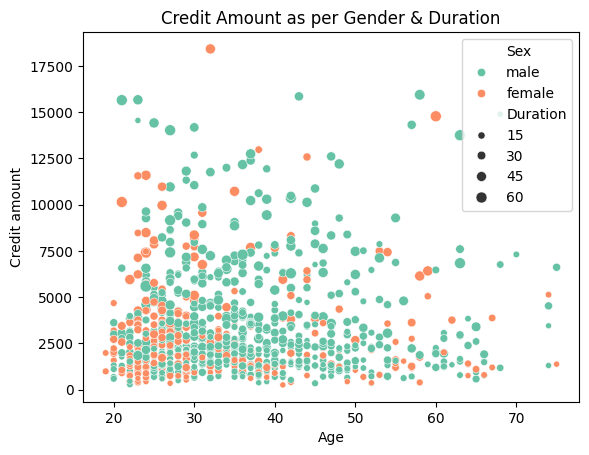

In [31]:
sns.scatterplot(df, x='Age',y='Credit amount',hue='Sex',size='Duration', palette='Set2')
plt.title('Credit Amount as per Gender & Duration')

In [32]:
df.head(2)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,little,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad


Text(0.5, 1.0, 'Credit amount distribution by savings account')

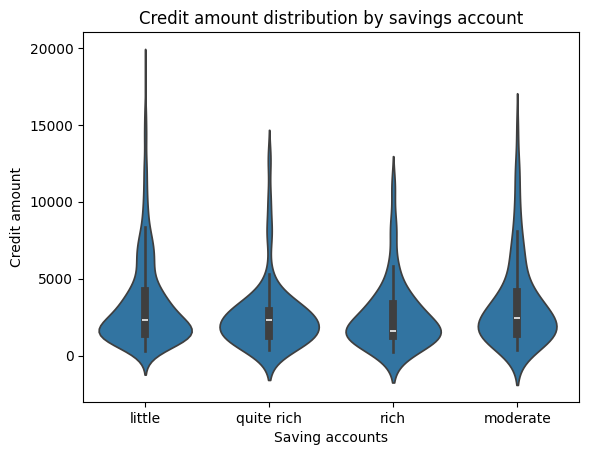

In [33]:
sns.violinplot(df, x='Saving accounts',y='Credit amount')
plt.title('Credit amount distribution by savings account')

Text(0.5, 1.0, 'Credit amount distribution by checking account')

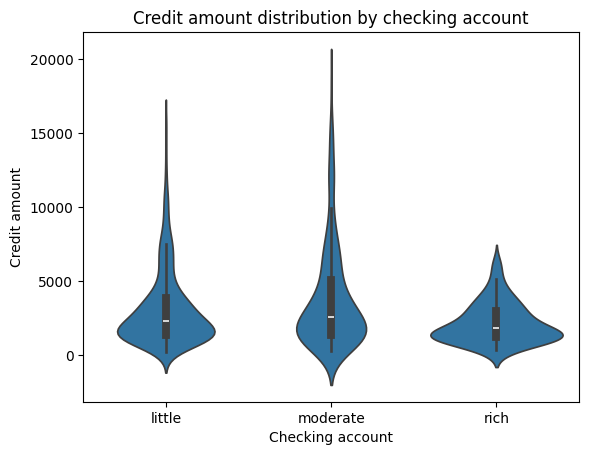

In [34]:
sns.violinplot(df, x='Checking account',y='Credit amount')
plt.title('Credit amount distribution by checking account')

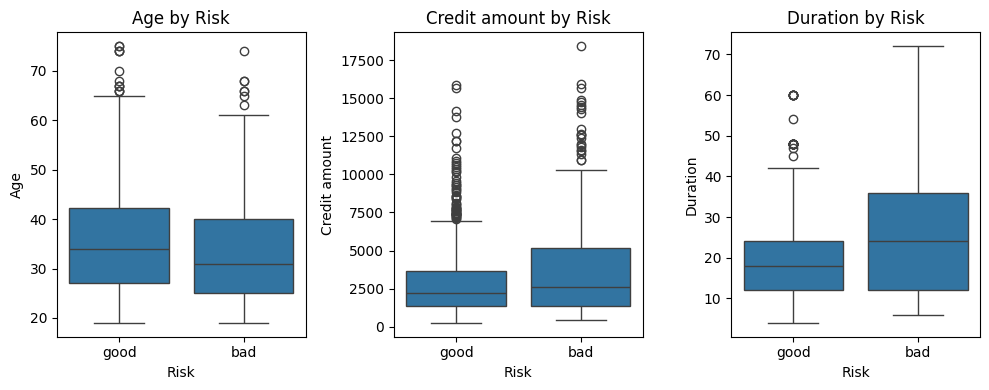

In [35]:
plt.figure(figsize=(10,4))
for i,col in enumerate(['Age','Credit amount','Duration']):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df,x='Risk',y=col)
    plt.title(f"{col} by Risk")
plt.tight_layout()
plt.show()

In [36]:
df.groupby('Risk')[['Age','Credit amount','Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,33.963333,3938.126667,24.860000
good,36.224286,2985.457143,19.207143


In [37]:
df['Sex'].value_counts().index

Index(['male', 'female'], dtype='object', name='Sex')

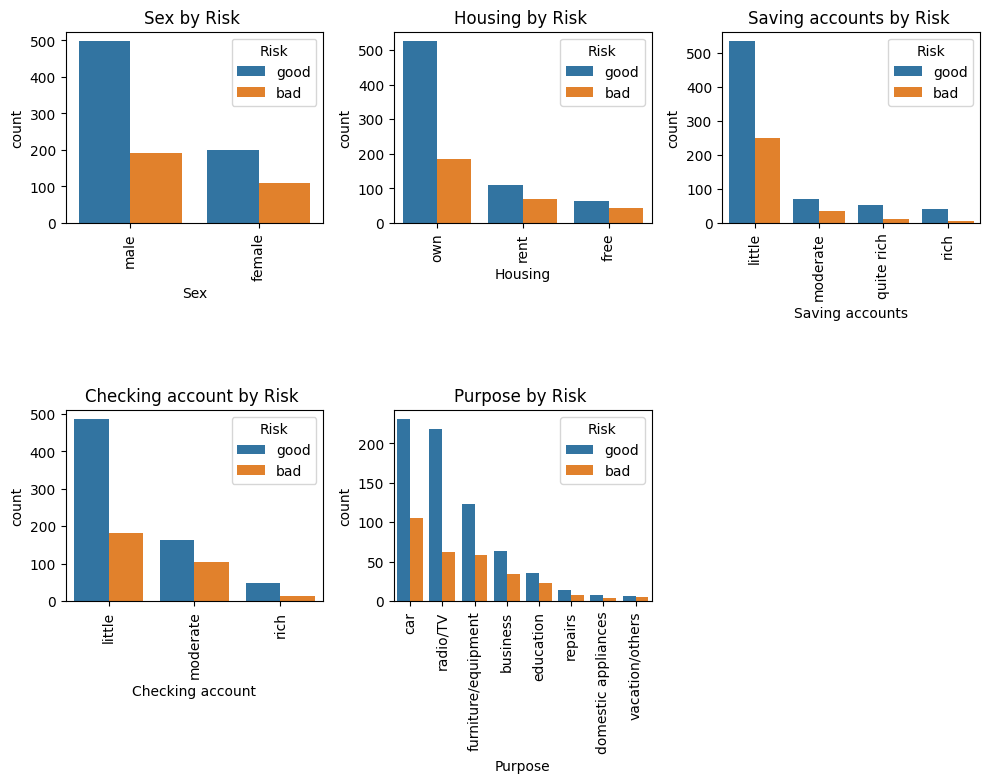

In [38]:
plt.figure(figsize=(10,10))
for i,col in enumerate(category_col):
    plt.subplot(3,3,i+1)
    sns.countplot(df,x=col, hue='Risk', order=df[col].value_counts().index)
    plt.xticks(rotation=90)
    plt.title(f"{col} by Risk ")

plt.tight_layout()
plt.show()

In [103]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [104]:
features = df.columns.drop('Risk').tolist()
features

['Age',
 'Sex',
 'Job',
 'Housing',
 'Saving accounts',
 'Checking account',
 'Credit amount',
 'Duration',
 'Purpose']

In [ ]:
# features.append('Age')
# features.remove('Purpose')
# features.remove('Credit amount')

In [54]:
# features = category_col
target = 'Risk'

In [105]:
df_model = df[features+[target]].copy()
df_model.head(5)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,little,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,little,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [107]:
df_model['Purpose'].value_counts()

Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

In [106]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   1000 non-null   object
 5   Checking account  1000 non-null   object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [108]:
from sklearn.preprocessing import LabelEncoder
import joblib
le_dict={}
for col in features:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f'le_{col}_encoder.pkl')
    

In [109]:
le_dict

{'Age': LabelEncoder(),
 'Sex': LabelEncoder(),
 'Job': LabelEncoder(),
 'Housing': LabelEncoder(),
 'Saving accounts': LabelEncoder(),
 'Checking account': LabelEncoder(),
 'Credit amount': LabelEncoder(),
 'Duration': LabelEncoder(),
 'Purpose': LabelEncoder()}

In [110]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   int64 
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   int64 
 4   Saving accounts   1000 non-null   int64 
 5   Checking account  1000 non-null   int64 
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   int64 
 9   Risk              1000 non-null   object
dtypes: int64(9), object(1)
memory usage: 78.3+ KB


In [111]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,48,1,2,1,0,0,142,2,5,good
1,3,0,2,1,0,1,770,29,5,bad
2,30,1,1,1,0,0,390,8,3,good
3,26,1,2,0,0,0,848,26,4,good
4,34,1,2,0,0,0,734,17,1,bad


In [112]:
target_le = LabelEncoder()
df_model['Risk'] = target_le.fit_transform(df_model['Risk'])

In [113]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,48,1,2,1,0,0,142,2,5,1
1,3,0,2,1,0,1,770,29,5,0
2,30,1,1,1,0,0,390,8,3,1
3,26,1,2,0,0,0,848,26,4,1
4,34,1,2,0,0,0,734,17,1,0


In [114]:
df_model['Risk'].value_counts()

Risk
1    700
0    300
Name: count, dtype: int64

In [115]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

## 1 = good(lower risk)
## 0 = bad(high risk)

In [116]:
X = df_model.drop(columns='Risk',axis=1)
y=df_model['Risk']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)


In [117]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [118]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression(class_weight='balanced',random_state = 42)
log.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [119]:
y_pred = log.predict(X_test_scaled)

In [120]:
from sklearn.metrics import accuracy_score, classification_report
print(f"accuracy_score : {accuracy_score(y_test,y_pred)} ")
print(f"classification_report : \n {classification_report(y_test,y_pred)} ")

accuracy_score : 0.63 
classification_report : 
               precision    recall  f1-score   support

           0       0.42      0.63      0.51        60
           1       0.80      0.63      0.70       140

    accuracy                           0.63       200
   macro avg       0.61      0.63      0.61       200
weighted avg       0.69      0.63      0.64       200
 


In [121]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [122]:
def train_model(model,param_grid,X_train,X_test,y_train):
    grid = GridSearchCV(model,param_grid,cv=5,scoring='accuracy',n_jobs=-1)
    grid.fit(X_train,y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    cls_rpt = classification_report(y_test,y_pred)
    print(f"accuracy : {acc}")
    print(f"classification report : \n{cls_rpt} ")
    print(f"best params : {grid.best_params_} ")
    return best_model,acc, grid.best_params_

In [74]:
dt = DecisionTreeClassifier(random_state=42,class_weight='balanced')
dt_param_grid = {
    "max_depth":[3,5,7,10,None],
    'min_samples_split':[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [123]:
best_model, dt_acc, dt_best_params = train_model(dt,dt_param_grid,X_train,X_test,y_train)

accuracy : 0.6
classification report : 
              precision    recall  f1-score   support

           0       0.37      0.48      0.42        60
           1       0.75      0.65      0.69       140

    accuracy                           0.60       200
   macro avg       0.56      0.57      0.56       200
weighted avg       0.63      0.60      0.61       200
 
best params : {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2} 


In [127]:
rf = RandomForestClassifier(random_state=42,class_weight='balanced')
rf_param_grid = {
    "n_estimators":[100,200,500],
    "max_depth":[3,5,7,10,None],
    'min_samples_split':[2,5,10],
    "min_samples_leaf":[1,2,4]
}
rf_best_model, rf_acc, rf_best_params = train_model(rf,rf_param_grid,X_train,X_test,y_train)

accuracy : 0.725
classification report : 
              precision    recall  f1-score   support

           0       0.58      0.30      0.40        60
           1       0.75      0.91      0.82       140

    accuracy                           0.72       200
   macro avg       0.67      0.60      0.61       200
weighted avg       0.70      0.72      0.69       200
 
best params : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200} 


In [ ]:
extra = ExtraTreesClassifier(random_state=42, class_weight='balanced')
et_param_grid = {
    "n_estimators":[100,200,500],
    "max_depth":[3,5,7,10,None],
    'min_samples_split':[2,5,10],
    "min_samples_leaf":[1,2,4]
}
et_best_model, et_acc, et_best_params = train_model(extra,et_param_grid,X_train,X_test,y_train)

accuracy : 0.665
classification report : 
              precision    recall  f1-score   support

           0       0.41      0.27      0.32        60
           1       0.73      0.84      0.78       140

    accuracy                           0.67       200
   macro avg       0.57      0.55      0.55       200
weighted avg       0.63      0.67      0.64       200
 
best params : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500} 


In [ ]:
xgb = XGBClassifier(random_state=42,scale_pos_weight=(y_train == 0).sum()/(y_train==1).sum(), use_label_encoder=False,eval_metric='logloss')
xg_param_grid = {
    "n_estimators":[100,200,500],
    "max_depth":[3,5,7,10,None],
    "learning_rate":[0.01,0.1,0.2,0.5],
    'subsample':[0.7,1],
    "colsample_bytree":[0.7,1]
}
xg_best_model, xg_acc, xg_best_params = train_model(xgb,xg_param_grid,X_train,X_test,y_train)

c:\Users\Ann\Desktop\workspace\Model_risk_analytics\credit_risk_models\vrisk\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:41:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


accuracy : 0.615
classification report : 
              precision    recall  f1-score   support

           0       0.37      0.38      0.37        60
           1       0.73      0.71      0.72       140

    accuracy                           0.61       200
   macro avg       0.55      0.55      0.55       200
weighted avg       0.62      0.61      0.62       200
 
best params : {'colsample_bytree': 1, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.7} 


In [81]:
rf_best_model

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [128]:
import joblib
joblib.dump(rf_best_model, 'credit_risk_model.pkl')

['credit_risk_model.pkl']

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   1000 non-null   object
 5   Checking account  1000 non-null   object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [126]:
df_model['Job'].value_counts()

Job
2    630
1    200
3    148
0     22
Name: count, dtype: int64

In [131]:
df['Purpose'].value_counts().index

Index(['car', 'radio/TV', 'furniture/equipment', 'business', 'education',
       'repairs', 'domestic appliances', 'vacation/others'],
      dtype='object', name='Purpose')

In [132]:
df_model.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')